# XGBoost Training for EDA+Weather V2 Output

This notebook is designed for datasets generated by:
- `notebooks/data_preparation/build_trip_weather_eda_v2.ipynb`

Expected input pattern:
- `data/proceed/micro_mobility_training_data_*_weather_v2.csv`


In [14]:
from pathlib import Path
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

PROJECT_ROOT = (Path.cwd().resolve().parent.parent if Path.cwd().resolve().name == "model_training" else Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "proceed"

# Auto-pick latest weather_v2 file
candidates = sorted(DATA_DIR.glob("micro_mobility_training_data_*_weather_v2.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if not candidates:
    raise FileNotFoundError("No weather_v2 dataset found in data/proceed.")

DATA_PATH = candidates[0]
RUN_ID = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "model_training" / "xgboost" / "weather_v2" / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
plots_dir = ARTIFACT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("ARTIFACT_DIR:", ARTIFACT_DIR)


DATA_PATH: D:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\micro_mobility_training_data_2023_2024_weather_v2.csv
ARTIFACT_DIR: D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548


In [2]:
# Runtime controls (adjust for your machine)
CHUNK_SIZE = 300_000
HOLDOUT_DAYS = 7
MAX_TRAIN_ROWS = None
MAX_TEST_ROWS = None
RANDOM_STATE = 42


In [3]:
# Feature spec for weather_v2 schema
TARGET_COL = "net_demand"
DATE_COL = "date"
STATION_COL = "station"

NUMERIC_COLS = [
    "hour",
    "is_weekend",
    "lat",
    "lng",
    "day_of_week",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_24h",
    "rolling_mean_3h",
    "temp_2m",
    "rh_2m",
    "rain_mm",
    "snow_cm",
    "wind_kmh",
    "precip_mm",
    "cloud_cover",
    "cloud_low",
    "cloud_mid",
    "cloud_high",
    "is_raining",
    "is_snowing",
]

REQUIRED_COLS = [DATE_COL, STATION_COL, TARGET_COL] + NUMERIC_COLS
head = pd.read_csv(DATA_PATH, nrows=5)
missing = [c for c in REQUIRED_COLS if c not in head.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")
print("Schema check passed. Columns:", len(head.columns))


Schema check passed. Columns: 30


In [4]:
# Scan date range + null profile on selected fields
date_min, date_max = None, None
rows = 0
null_counts = None

for ch in pd.read_csv(DATA_PATH, usecols=REQUIRED_COLS, chunksize=CHUNK_SIZE):
    rows += len(ch)
    d = pd.to_datetime(ch[DATE_COL], errors="coerce")
    cmin, cmax = d.min(), d.max()
    if pd.notna(cmin):
        date_min = cmin if date_min is None else min(date_min, cmin)
    if pd.notna(cmax):
        date_max = cmax if date_max is None else max(date_max, cmax)

    if null_counts is None:
        null_counts = ch.isna().sum()
    else:
        null_counts += ch.isna().sum()

cutoff_date = date_max.normalize() - pd.Timedelta(days=HOLDOUT_DAYS)
print("rows:", rows)
print("date range:", date_min, "to", date_max)
print("cutoff_date:", cutoff_date)
display((null_counts / rows * 100).sort_values(ascending=False).to_frame("null_pct"))


rows: 43214544
date range: 2022-12-01 00:00:00 to 2024-12-31 00:00:00
cutoff_date: 2024-12-24 00:00:00


,null_pct
cloud_low,4.068241
temp_2m,4.068241
rh_2m,4.068241
cloud_high,4.068241
cloud_mid,4.068241
wind_kmh,4.068241
precip_mm,4.068241
cloud_cover,4.068241
snow_cm,4.068241
rain_mm,4.068241


In [5]:
# Build station encoding from full file
stations = set()
for ch in pd.read_csv(DATA_PATH, usecols=[STATION_COL], chunksize=CHUNK_SIZE):
    stations.update(ch[STATION_COL].dropna().unique().tolist())
station_list = sorted(stations)
station_to_id = {s: i for i, s in enumerate(station_list)}
print("unique stations:", len(station_to_id))


unique stations: 2363


In [6]:
# Put this in a cell before the split/build cell
if MAX_TRAIN_ROWS is None:
    MAX_TRAIN_ROWS = 10**15
if MAX_TEST_ROWS is None:
    MAX_TEST_ROWS = 10**15


In [7]:
def prep(ch: pd.DataFrame) -> pd.DataFrame:
    df = ch.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df.dropna(subset=[DATE_COL, STATION_COL, TARGET_COL])
    df["station_id"] = df[STATION_COL].map(station_to_id).astype("int32")
    return df

feature_cols = ["station_id"] + NUMERIC_COLS
train_X_parts, train_y_parts, test_X_parts, test_y_parts = [], [], [], []
train_rows, test_rows = 0, 0
train_date_min = train_date_max = None
test_date_min = test_date_max = None

for ch in pd.read_csv(DATA_PATH, usecols=REQUIRED_COLS, chunksize=CHUNK_SIZE):
    df = prep(ch)
    tr_mask = df[DATE_COL] <= cutoff_date
    te_mask = df[DATE_COL] > cutoff_date

    if train_rows < MAX_TRAIN_ROWS and tr_mask.any():
        tr = df.loc[tr_mask, [DATE_COL, TARGET_COL] + feature_cols]
        remain = MAX_TRAIN_ROWS - train_rows
        if len(tr) > remain:
            tr = tr.iloc[:remain]
        train_rows += len(tr)
        train_X_parts.append(tr[feature_cols].astype("float32"))
        train_y_parts.append(tr[TARGET_COL].astype("float32"))
        train_date_min = tr[DATE_COL].min() if train_date_min is None else min(train_date_min, tr[DATE_COL].min())
        train_date_max = tr[DATE_COL].max() if train_date_max is None else max(train_date_max, tr[DATE_COL].max())

    if test_rows < MAX_TEST_ROWS and te_mask.any():
        te = df.loc[te_mask, [DATE_COL, TARGET_COL] + feature_cols]
        remain = MAX_TEST_ROWS - test_rows
        if len(te) > remain:
            te = te.iloc[:remain]
        test_rows += len(te)
        test_X_parts.append(te[feature_cols].astype("float32"))
        test_y_parts.append(te[TARGET_COL].astype("float32"))
        test_date_min = te[DATE_COL].min() if test_date_min is None else min(test_date_min, te[DATE_COL].min())
        test_date_max = te[DATE_COL].max() if test_date_max is None else max(test_date_max, te[DATE_COL].max())

    if train_rows >= MAX_TRAIN_ROWS and test_rows >= MAX_TEST_ROWS:
        break

    del df
    gc.collect()

X_train = pd.concat(train_X_parts, ignore_index=True)
y_train = pd.concat(train_y_parts, ignore_index=True)
X_test = pd.concat(test_X_parts, ignore_index=True)
y_test = pd.concat(test_y_parts, ignore_index=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("train range:", train_date_min, "to", train_date_max)
print("test range:", test_date_min, "to", test_date_max)


X_train: (42817560, 27) X_test: (396984, 27)
train range: 2022-12-01 00:00:00 to 2024-12-24 00:00:00
test range: 2024-12-25 00:00:00 to 2024-12-31 00:00:00


In [8]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="rmse",
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)


[0]	validation_0-rmse:1.49618
[100]	validation_0-rmse:1.47828
[200]	validation_0-rmse:1.47767
[300]	validation_0-rmse:1.47685
[400]	validation_0-rmse:1.47631
[499]	validation_0-rmse:1.47616


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


RMSE: 1.4762
MAE : 0.7413


,hour,mae
0,0,0.508972
1,1,0.351924
2,2,0.227316
3,3,0.163890
4,4,0.160747
5,5,0.246131
6,6,0.437472
7,7,0.598412
8,8,0.759183
9,9,0.818462


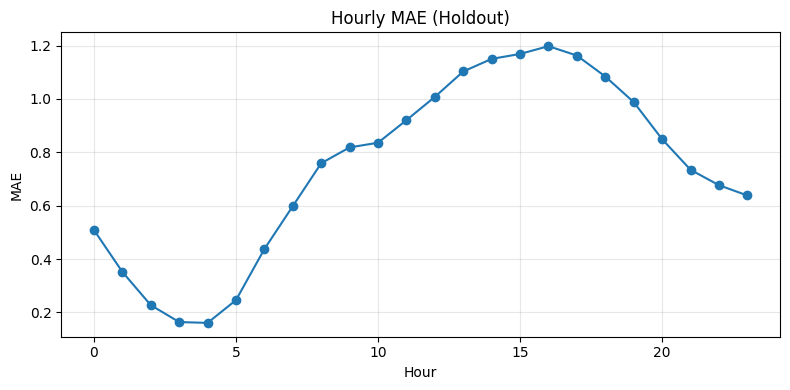

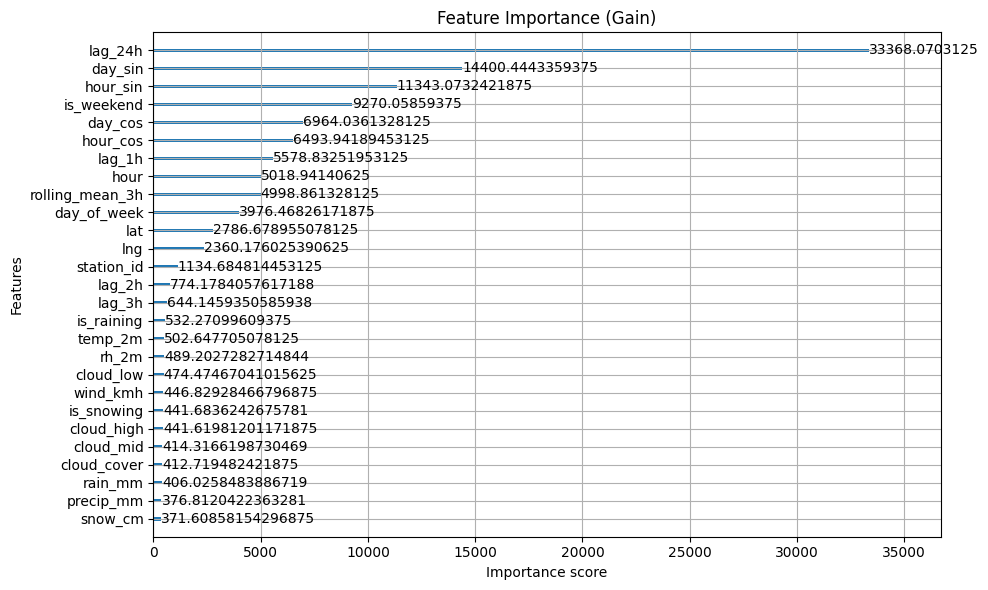

In [15]:
pred = model.predict(X_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
mae = float(mean_absolute_error(y_test, pred))
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

eval_df = pd.DataFrame({"hour": X_test["hour"].astype(int), "y_true": y_test, "y_pred": pred})
eval_df["abs_err"] = (eval_df["y_true"] - eval_df["y_pred"]).abs()
hourly_mae = eval_df.groupby("hour", as_index=False)["abs_err"].mean().rename(columns={"abs_err": "mae"})
display(hourly_mae.sort_values("hour"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_mae["hour"], hourly_mae["mae"], marker="o")
ax.set_title("Hourly MAE (Holdout)")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(plots_dir / "hourly_mae.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, max_num_features=len(X_train.columns), importance_type="gain", title="Feature Importance (Gain)")
fig.tight_layout()
fig.savefig(plots_dir / "feature_importance_gain.png", dpi=200, bbox_inches="tight")
plt.show()

imp = model.get_booster().get_score(importance_type="gain")
imp_df = pd.DataFrame({"feature": list(imp.keys()), "gain": list(imp.values())}).sort_values("gain", ascending=False)
imp_df.to_csv(ARTIFACT_DIR / "feature_importance_gain.csv", index=False)


In [16]:
model_path = ARTIFACT_DIR / "xgb_model.json"
metrics_path = ARTIFACT_DIR / "metrics.json"
hourly_path = ARTIFACT_DIR / "hourly_mae.csv"
features_path = ARTIFACT_DIR / "features_used.json"

model.save_model(model_path)
hourly_mae.to_csv(hourly_path, index=False)

metrics = {
    "run_id": RUN_ID,
    "data_path": str(DATA_PATH),
    "mae": mae,
    "rmse": rmse,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "date_min": str(date_min),
    "date_max": str(date_max),
    "cutoff_date": str(cutoff_date),
    "train_date_min": str(train_date_min),
    "train_date_max": str(train_date_max),
    "test_date_min": str(test_date_min),
    "test_date_max": str(test_date_max),
}
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

feature_meta = {
    "target": TARGET_COL,
    "numeric_features": NUMERIC_COLS,
    "station_encoding": "station_id (stable integer mapping)",
    "final_feature_columns": ["station_id"] + NUMERIC_COLS,
}
features_path.write_text(json.dumps(feature_meta, indent=2), encoding="utf-8")

print("Saved:")
print(" -", model_path)
print(" -", metrics_path)
print(" -", hourly_path)
print(" -", features_path)
print(" -", ARTIFACT_DIR / "feature_importance_gain.csv")
print(" -", plots_dir / "hourly_mae.png")
print(" -", plots_dir / "feature_importance_gain.png")


Saved:
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\xgb_model.json
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\metrics.json
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\hourly_mae.csv
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\features_used.json
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\feature_importance_gain.csv
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\plots\hourly_mae.png
 - D:\AIT\ML\project\citibike-netdemand-prediction\artifacts\model_training\xgboost\weather_v2\20260405_225548\plots\feature_importance_gain.png
